# Fase 6: Analise Visual do Resize Adaptativo

Notebook de auditoria visual para comparar, em cinco cenarios reais, o fluxo completo:
1. Imagem original + lesao anotada
2. BBox com padding de 40%
3. Crop obtido
4. Resize tradicional direto para 384x384
5. Resize adaptativo com limite de upscale
6. Saida final com preenchimento por contexto real da imagem original

In [1]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt

BASE = '.'
DIR_IMAGES = os.path.join(BASE, '../../data/images')
DIR_ANN = os.path.join(BASE, '../../data/Annotations')
OUT_DIR = os.path.join(BASE, 'plots_resize_cenarios')
os.makedirs(OUT_DIR, exist_ok=True)

TARGET = 384
PADDING = 0.40
S_MAX = 1.5  # limite maximo de upscaling para evitar interpolacao agressiva

SCENARIOS = {
    'A_muito_pequeno': 'IMG000826.jpeg',   # 68x77
    'B_pequeno_medio': 'IMG000902.jpeg',  # 65x173
    'C_proximo_alvo': 'IMG000163.jpeg',   # 135x383
    'D_maior_que_384_em_um_eixo': 'IMG001652.jpeg',  # 316x493
    'E_muito_grande': 'IMG001459.jpeg'    # 965x1154
}

print('Cenarios carregados:')
for k, v in SCENARIOS.items():
    print(f'- {k}: {v}')

Cenarios carregados:
- A_muito_pequeno: IMG000826.jpeg
- B_pequeno_medio: IMG000902.jpeg
- C_proximo_alvo: IMG000163.jpeg
- D_maior_que_384_em_um_eixo: IMG001652.jpeg
- E_muito_grande: IMG001459.jpeg


In [2]:
def find_original_image_by_stem(filename):
    stem = os.path.splitext(filename)[0]
    direct = os.path.join(DIR_IMAGES, filename)
    if os.path.exists(direct):
        return direct

    for fn in os.listdir(DIR_IMAGES):
        if os.path.splitext(fn)[0] == stem:
            return os.path.join(DIR_IMAGES, fn)
    return None

def load_annotation(filename):
    stem = os.path.splitext(filename)[0]
    path_json = os.path.join(DIR_ANN, f'{stem}.json')
    if not os.path.exists(path_json):
        return None
    with open(path_json, 'r', encoding='utf-8') as f:
        return json.load(f)

def calcular_bbox_geral(shapes):
    all_points = []
    for shape in shapes:
        for p in shape.get('points', []):
            all_points.append(p)
    if not all_points:
        return None
    pts = np.array(all_points)
    return int(np.min(pts[:, 0])), int(np.min(pts[:, 1])), int(np.max(pts[:, 0])), int(np.max(pts[:, 1]))

def apply_padding_to_bbox(bbox, img_shape, padding=PADDING):
    x1, y1, x2, y2 = bbox
    h, w = img_shape[:2]
    pad_x = int((x2 - x1) * padding)
    pad_y = int((y2 - y1) * padding)

    nx1 = max(0, x1 - pad_x)
    ny1 = max(0, y1 - pad_y)
    nx2 = min(w, x2 + pad_x)
    ny2 = min(h, y2 + pad_y)
    return nx1, ny1, nx2, ny2

def extract_crop(img, bbox_pad):
    x1, y1, x2, y2 = bbox_pad
    return img[y1:y2, x1:x2]

def extract_window_with_border(img, x1, y1, x2, y2):
    h, w = img.shape[:2]

    pad_left = max(0, -x1)
    pad_top = max(0, -y1)
    pad_right = max(0, x2 - w)
    pad_bottom = max(0, y2 - h)

    x1c = max(0, x1)
    y1c = max(0, y1)
    x2c = min(w, x2)
    y2c = min(h, y2)

    window = img[y1c:y2c, x1c:x2c]
    if pad_left or pad_top or pad_right or pad_bottom:
        window = cv2.copyMakeBorder(window, pad_top, pad_bottom, pad_left, pad_right, cv2.BORDER_REPLICATE)
    return window

def resize_tradicional(crop, target=TARGET):
    return cv2.resize(crop, (target, target), interpolation=cv2.INTER_CUBIC)

def resize_adaptativo_com_contexto(crop, img_original, bbox_pad, target=TARGET, s_max=S_MAX):
    h, w = crop.shape[:2]
    s_fit = min(target / w, target / h)

    if s_fit > 1:
        s = min(s_fit, s_max)
    else:
        s = s_fit

    new_w = max(1, int(round(w * s)))
    new_h = max(1, int(round(h * s)))

    interp = cv2.INTER_CUBIC if s > 1 else cv2.INTER_AREA
    crop_resized = cv2.resize(crop, (new_w, new_h), interpolation=interp)

    # Visual auxiliar: crop redimensionado em canvas preto
    canvas_black = np.zeros((target, target, 3), dtype=np.uint8)
    ox = (target - new_w) // 2
    oy = (target - new_h) // 2
    canvas_black[oy:oy+new_h, ox:ox+new_w] = crop_resized

    # Contexto real: busca janela na imagem original e redimensiona para o alvo
    x1, y1, x2, y2 = bbox_pad
    cx = (x1 + x2) // 2
    cy = (y1 + y2) // 2

    ctx_w = max(1, int(round(target / max(s, 1e-6))))
    ctx_h = max(1, int(round(target / max(s, 1e-6))))

    wx1 = cx - ctx_w // 2
    wy1 = cy - ctx_h // 2
    wx2 = wx1 + ctx_w
    wy2 = wy1 + ctx_h

    context_window = extract_window_with_border(img_original, wx1, wy1, wx2, wy2)
    interp_bg = cv2.INTER_AREA if (context_window.shape[1] > target or context_window.shape[0] > target) else cv2.INTER_CUBIC
    context_bg = cv2.resize(context_window, (target, target), interpolation=interp_bg)

    # Sobrepoe ROI redimensionada no centro (pixels restantes permanecem reais)
    final = context_bg.copy()
    final[oy:oy+new_h, ox:ox+new_w] = crop_resized

    return {
        's_fit': s_fit,
        's_used': s,
        'crop_resized': crop_resized,
        'canvas_black': canvas_black,
        'context_bg': context_bg,
        'final': final
    }

def draw_original_with_annotations(img_bgr, ann, bbox, bbox_pad):
    out = img_bgr.copy()

    for shape in ann.get('shapes', []):
        pts = np.array(shape.get('points', []), dtype=np.int32)
        if len(pts) >= 3:
            cv2.polylines(out, [pts], isClosed=True, color=(255, 255, 0), thickness=2)

    x1, y1, x2, y2 = bbox
    cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)

    px1, py1, px2, py2 = bbox_pad
    cv2.rectangle(out, (px1, py1), (px2, py2), (0, 128, 255), 2)

    return out

In [3]:
def plot_scenario(nome_cenario, arquivo):
    path_img = find_original_image_by_stem(arquivo)
    ann = load_annotation(arquivo)

    if path_img is None or ann is None:
        print(f'[ERRO] Falta imagem/anotacao para {arquivo}')
        return

    img_bgr = cv2.imread(path_img)
    if img_bgr is None:
        print(f'[ERRO] Nao foi possivel ler {path_img}')
        return

    bbox = calcular_bbox_geral(ann.get('shapes', []))
    if bbox is None:
        print(f'[ERRO] Sem bbox valida em {arquivo}')
        return

    bbox_pad = apply_padding_to_bbox(bbox, img_bgr.shape, padding=PADDING)
    crop = extract_crop(img_bgr, bbox_pad)

    if crop.size == 0:
        print(f'[ERRO] Crop vazio para {arquivo}')
        return

    trad = resize_tradicional(crop, target=TARGET)
    adap = resize_adaptativo_com_contexto(crop, img_bgr, bbox_pad, target=TARGET, s_max=S_MAX)

    img_annot = draw_original_with_annotations(img_bgr, ann, bbox, bbox_pad)

    vis = [
        ('Original + Anotacao/BBox', img_annot),
        (f'Crop +40% ({crop.shape[1]}x{crop.shape[0]})', crop),
        ('Resize Tradicional 384x384', trad),
        ('Adaptativo (s_fit={:.2f}, s={:.2f})'.format(adap['s_fit'], adap['s_used']), adap['canvas_black']),
        ('Contexto real (background)', adap['context_bg']),
        ('Final Adaptativo 384x384', adap['final'])
    ]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'{nome_cenario} | Arquivo: {arquivo} | Target={TARGET} | S_MAX={S_MAX}', fontsize=13, fontweight='bold')

    for ax, (title, img) in zip(axes.flatten(), vis):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, f'{nome_cenario}_{os.path.splitext(arquivo)[0]}.png')
    plt.savefig(out_path, dpi=180, bbox_inches='tight')
    plt.show()

    print(f'[OK] {nome_cenario}: salvo em {out_path}')

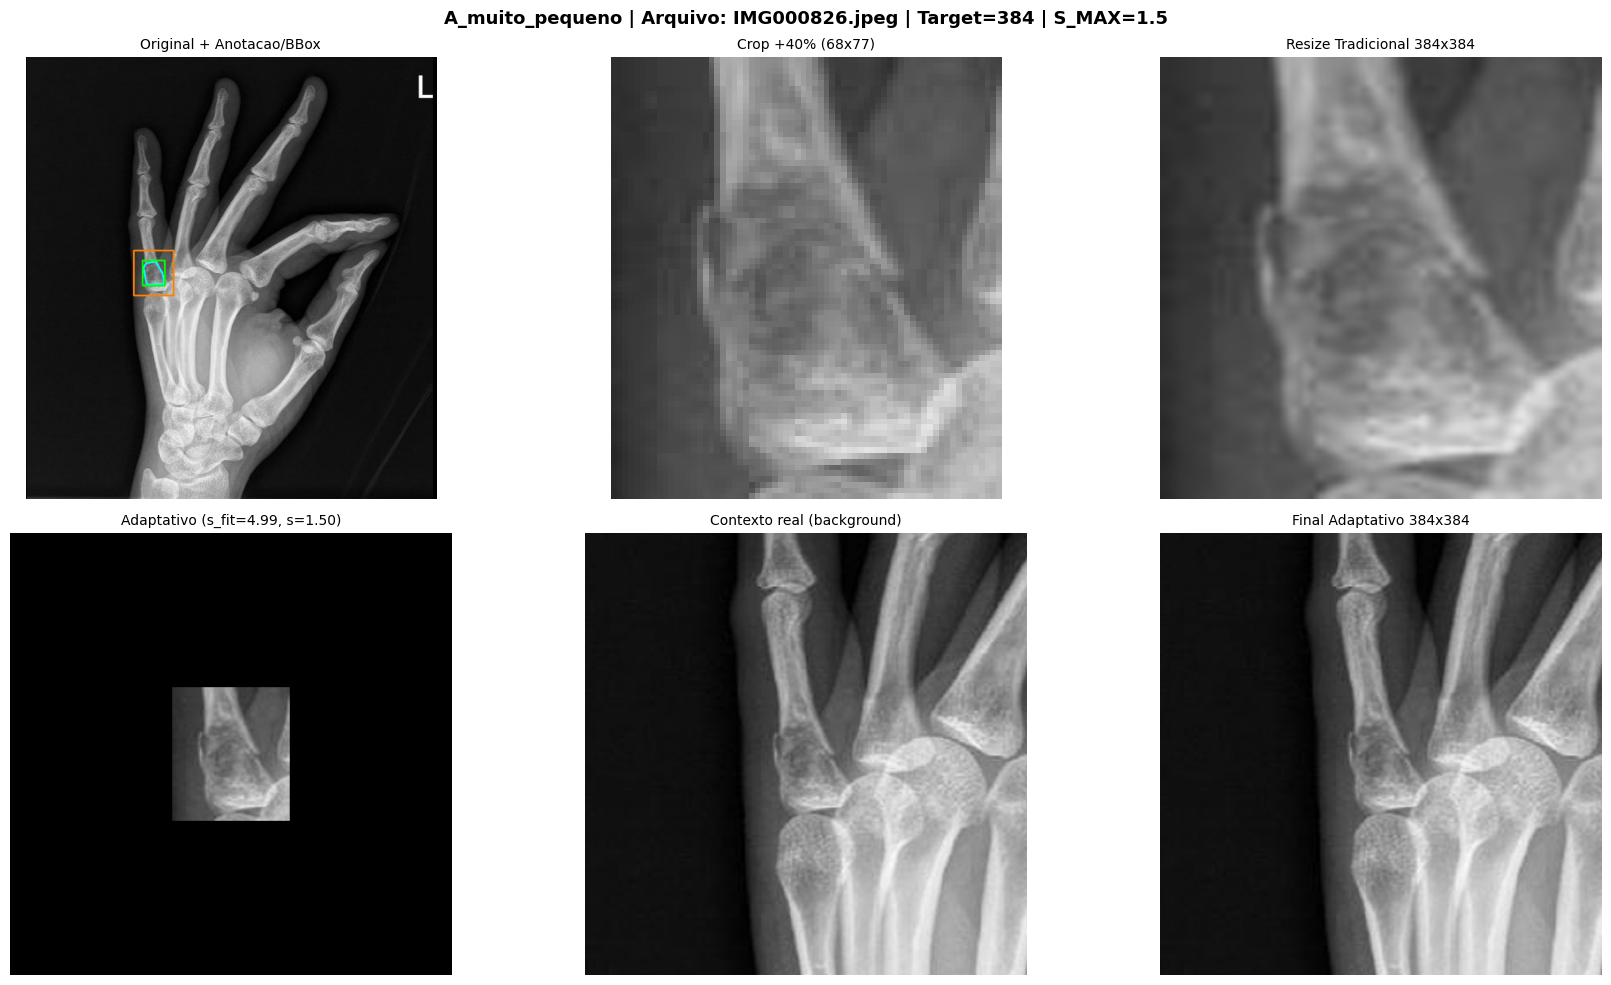

[OK] A_muito_pequeno: salvo em .\plots_resize_cenarios\A_muito_pequeno_IMG000826.png



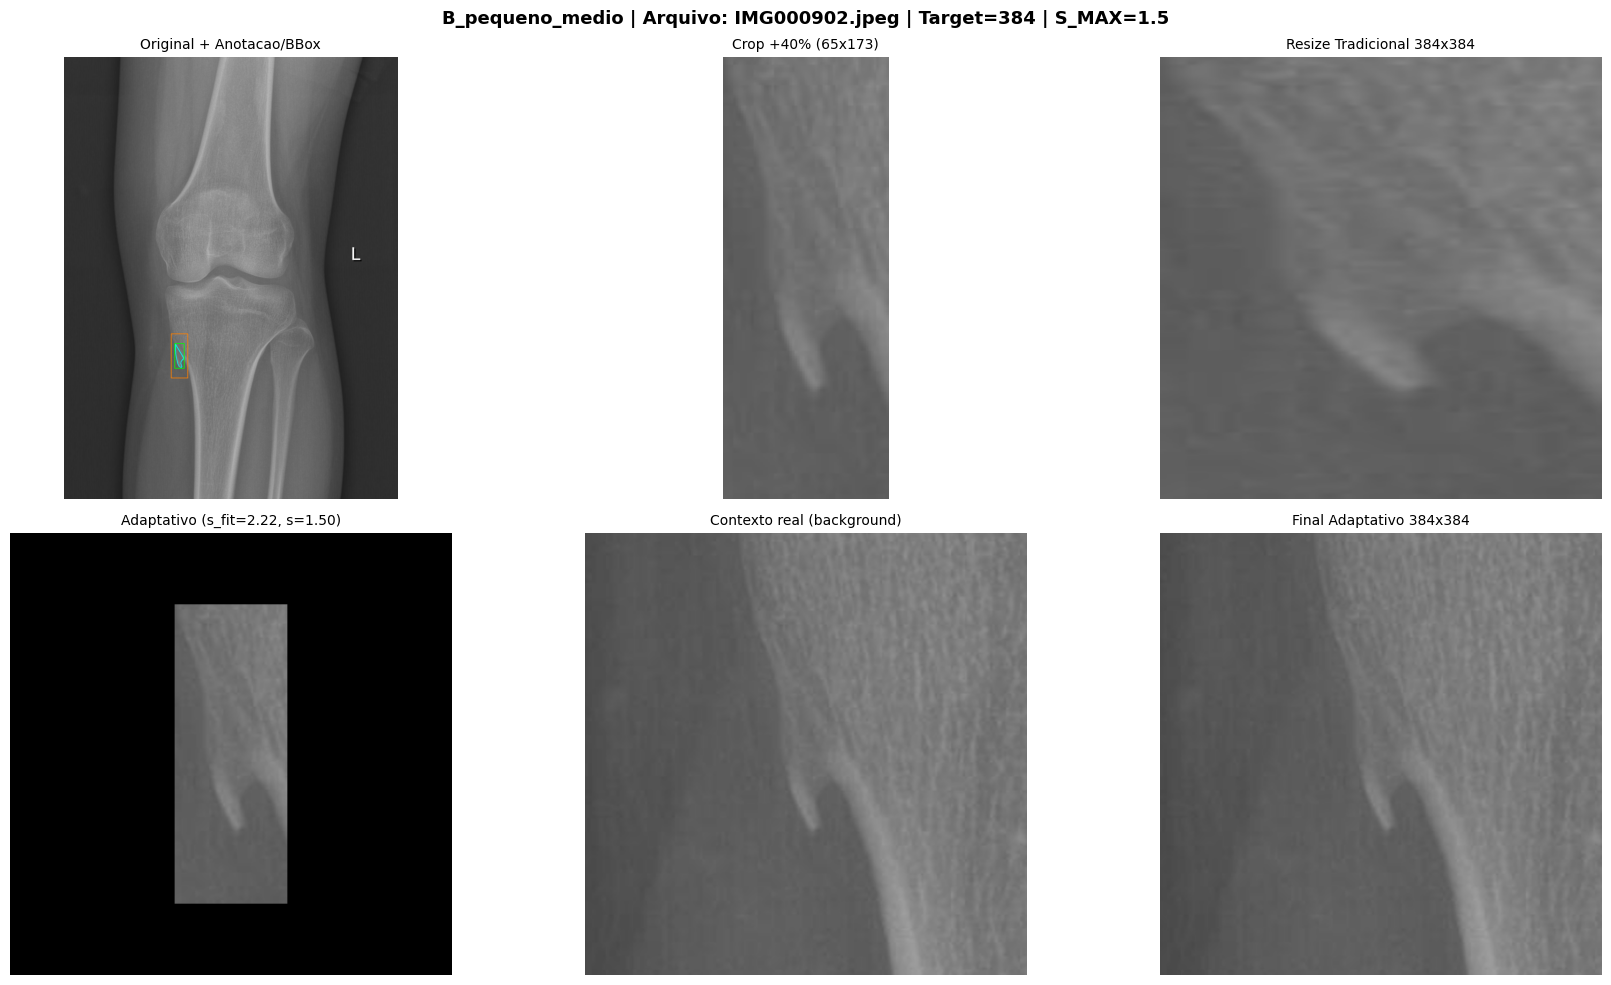

[OK] B_pequeno_medio: salvo em .\plots_resize_cenarios\B_pequeno_medio_IMG000902.png



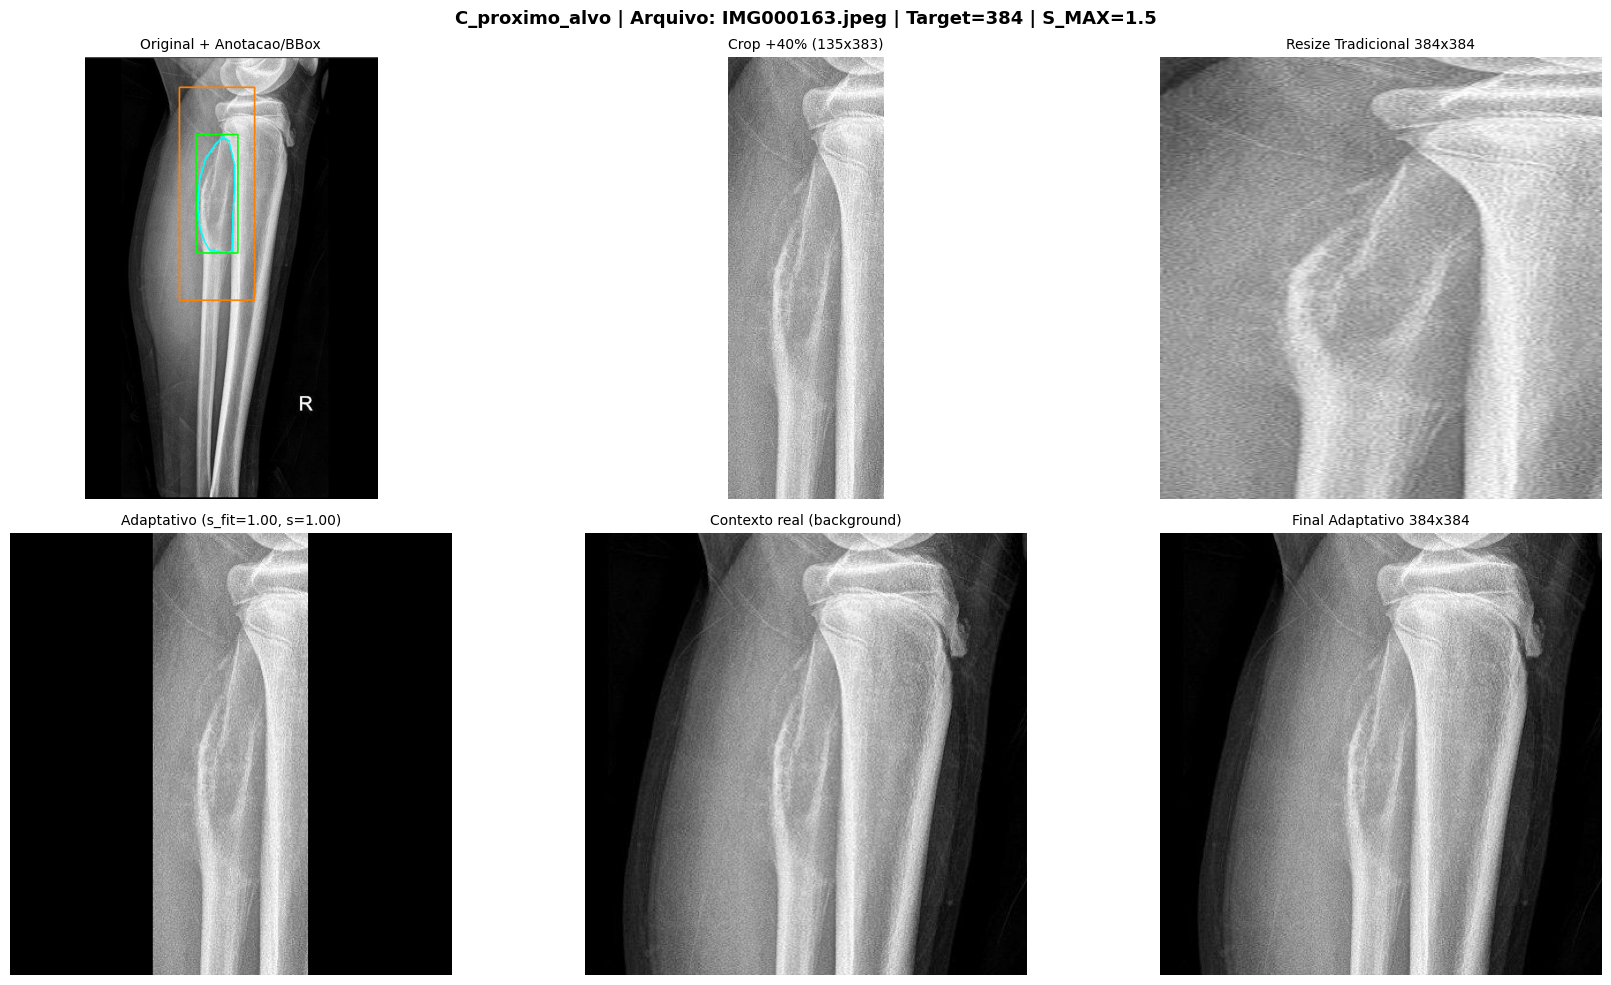

[OK] C_proximo_alvo: salvo em .\plots_resize_cenarios\C_proximo_alvo_IMG000163.png



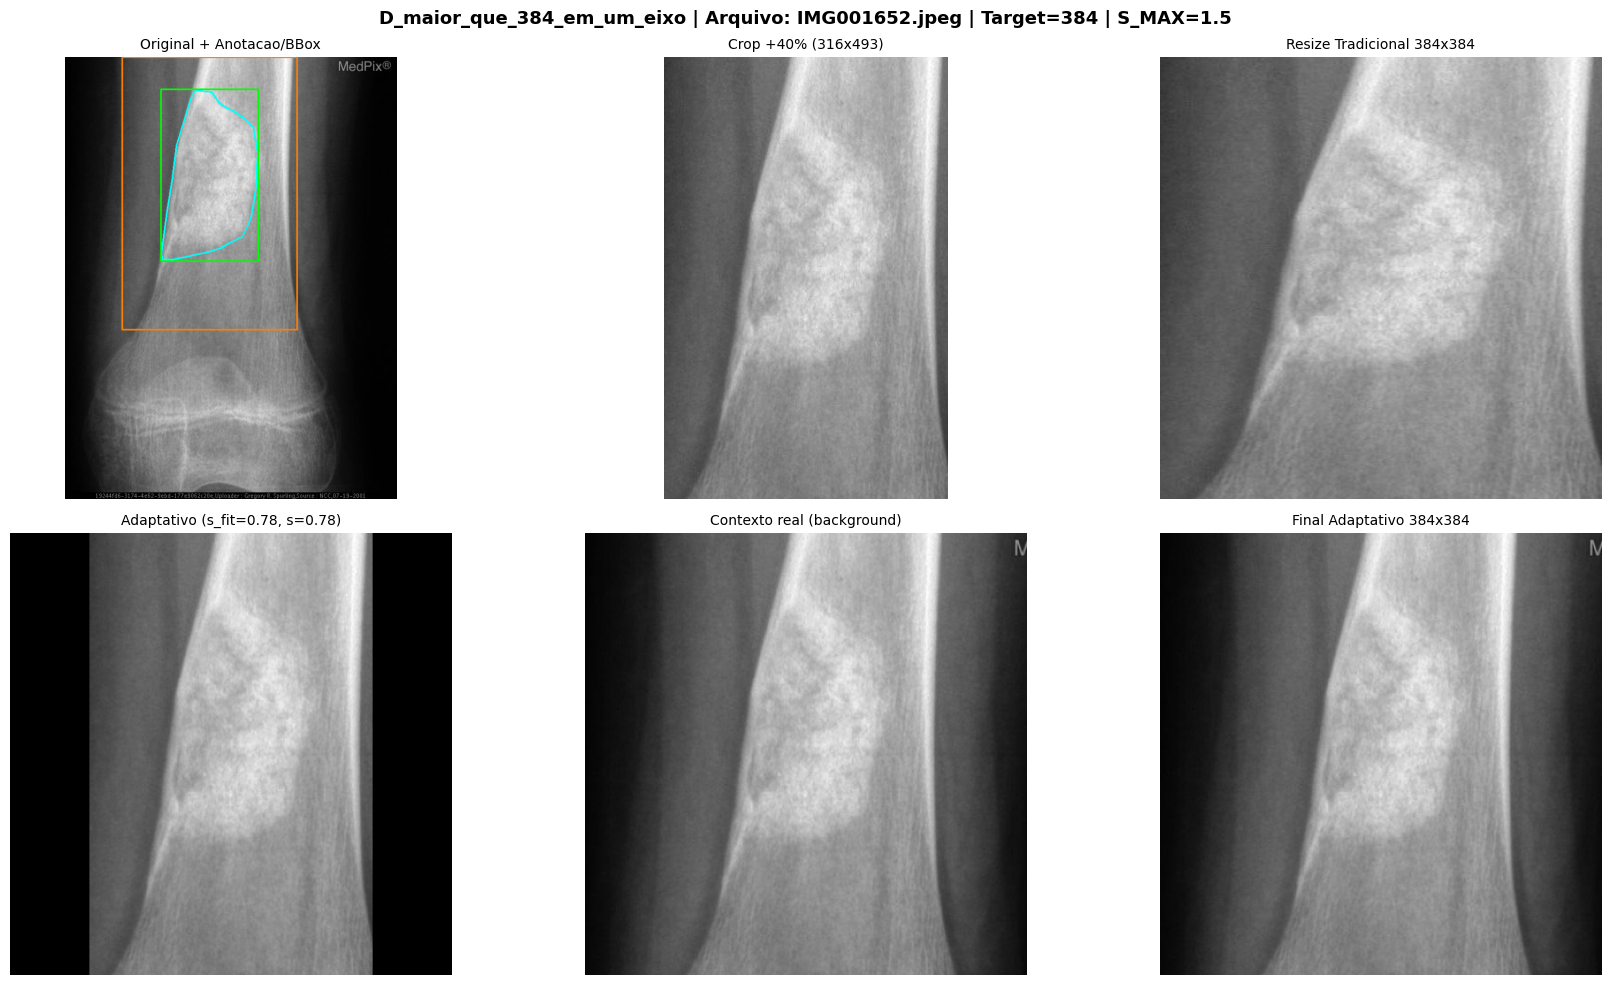

[OK] D_maior_que_384_em_um_eixo: salvo em .\plots_resize_cenarios\D_maior_que_384_em_um_eixo_IMG001652.png



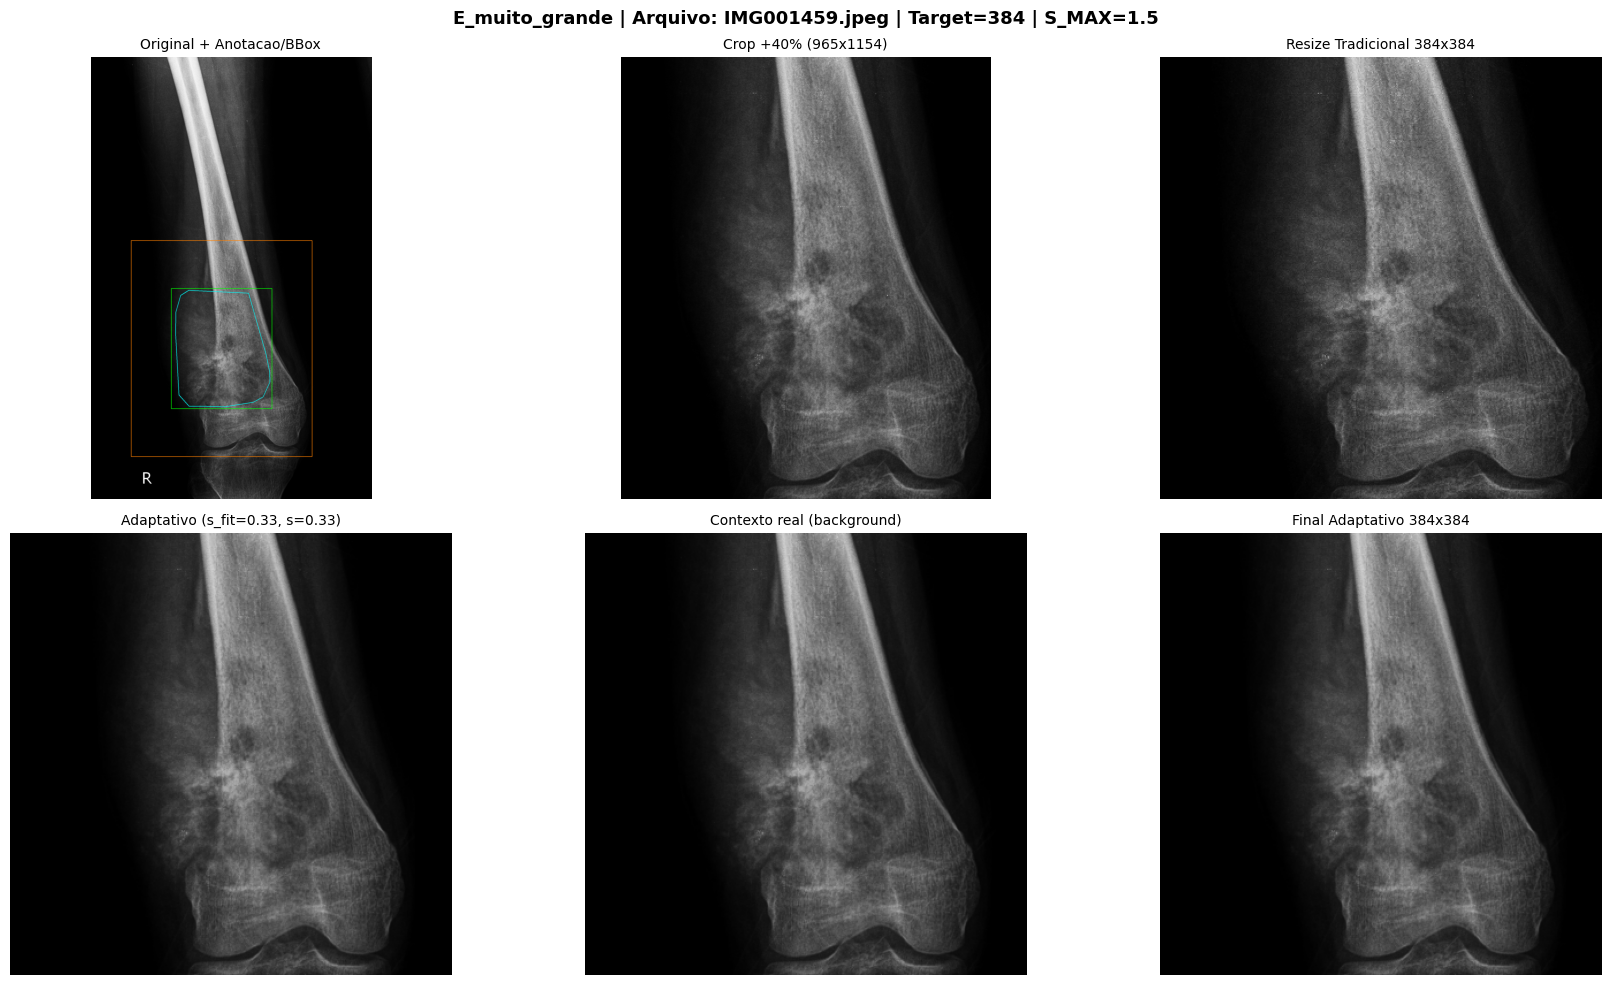

[OK] E_muito_grande: salvo em .\plots_resize_cenarios\E_muito_grande_IMG001459.png

Concluido. Figuras em: c:\Users\jffil\OneDrive\Área de Trabalho\FRELA\TCC\fases\Fase6\plots_resize_cenarios


In [4]:
for nome_cenario, arquivo in SCENARIOS.items():
    print('\n' + '=' * 90)
    plot_scenario(nome_cenario, arquivo)

print('\nConcluido. Figuras em:', os.path.abspath(OUT_DIR))

## Como interpretar

- Compare o painel "Resize Tradicional 384x384" com "Final Adaptativo 384x384".
- Nos casos pequenos, o adaptativo tende a evitar textura artificial por esticamento extremo.
- Nos casos grandes, o adaptativo reduz de forma controlada mantendo proporcao e contexto anatomico.
- Ajuste `S_MAX` (ex.: 1.5, 2.0) para testar sensibilidade da tecnica antes de integrar ao pipeline de treino.